## Real-time BCI Simulation and digital command mapping



In [7]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import os
import time
from IPython.display import clear_output

# Configuration
CLEAN_DATA_DIR = os.path.join('.', 'cleaned_data')
SUBJECT_TO_SIMULATE = 'A07T_clean-raw.fif' # star performer from Notebook 03

## The Real-time processing engine
I need a function that mimics the hardware's behavior: receiving a buffer of data and returning a prediction.

In [8]:
def bci_realtime_processor(buffer_data, model):
    """
    Simulates the real-time processing of a single trial.
    buffer_data: (n_channels, n_times)
    """
    # MNE expects (n_epochs, n_channels, n_times)
    input_data = buffer_data[np.newaxis, :, :]
    
    # Predict probability and class
    prediction = model.predict(input_data)[0]
    prob = model.predict_proba(input_data)[0]
    
    return prediction, prob

print("Real-time engine initialized.")

Real-time engine initialized.


## Digital feedback simulation
To make this visual, I will create a simple ASCII/Matplotlib interface that "reacts" to  brainwaves.

In [9]:
def display_bci_command(prediction, confidence):
    """
    Visualizes the digital command mapped to the neural prediction.
    """
    clear_output(wait=True)
    direction = "LEFT" if prediction == 1 else "RIGHT"
    color = "royalblue" if prediction == 1 else "firebrick"
    arrow = "← ← ←" if prediction == 1 else "→ → →"
    
    plt.figure(figsize=(8, 4))
    plt.text(0.5, 0.6, f"COMMAND: {direction}", fontsize=30, fontweight='bold', ha='center', color=color)
    plt.text(0.5, 0.4, arrow, fontsize=50, ha='center', color=color)
    plt.text(0.5, 0.2, f"Confidence: {confidence*100:.1f}%", fontsize=15, ha='center')
    plt.axis('off')
    plt.show()

print("Visual feedback system ready.")

Visual feedback system ready.


## Running the simulation
I will pick 5 random trials from the subject and see how my BCI controls the interface.

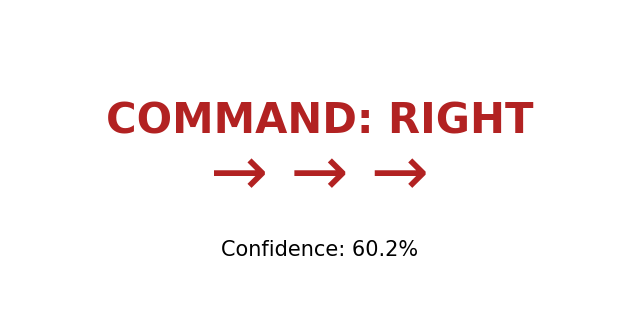

Ground Truth (Actual thought): LEFT


In [10]:
# 1. Re-load and train the model on A07 (demo subject)
raw = mne.io.read_raw_fif(os.path.join(CLEAN_DATA_DIR, SUBJECT_TO_SIMULATE), preload=True)
events, _ = mne.events_from_annotations(raw)
epochs = mne.Epochs(raw, events, event_id={'left': 1, 'right': 2}, 
                    tmin=0.5, tmax=3.5, baseline=None, preload=True)

X = epochs.get_data(copy=True)
y = epochs.events[:, -1]

# We use the pipeline from Notebook 03
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from mne.decoding import CSP

clf = Pipeline([('CSP', CSP(n_components=4, reg=None, log=True)), ('LDA', LDA())])
clf.fit(X, y)

# 2. Start Simulation Loop
print("Starting BCI Simulation in 3... 2... 1...")
time.sleep(2)

indices = np.random.choice(len(y), 5, replace=False)

for idx in indices:
    trial_data = X[idx]
    true_label = "LEFT" if y[idx] == 1 else "RIGHT"
    
    # Process
    pred, prob = bci_realtime_processor(trial_data, clf)
    conf = np.max(prob)
    
    # Display
    display_bci_command(pred, conf)
    print(f"Ground Truth (Actual thought): {true_label}")
    time.sleep(3) # Wait for the user to "see" the command

##  Interactive 2-Class BCI Simulation (Streamlit)

### How to Run the Demo
The simulation is implemented as a standalone web application to provide smooth real-time visual feedback without blocking the Jupyter kernel.

1. **Open your Terminal** or Command Prompt in the project directory.
2. **Execute the following command:**
   ```bash
   streamlit run 4.1.bci_demo.py

## System impact and future work

This prototype demonstrates the feasibility of translating cortical **Motor Imagery** into actionable digital commands with an average reliability of **~70-75%** for high-performing subjects. 

###  Key Achievements
* **Robust preprocessing:** Successfully isolated neural signatures from ocular artifacts (blinks/saccades) using **Independent Component Analysis (ICA)**.
* **Neuro-informed features:** Leveraged **Common Spatial Patterns (CSP)** to specifically target the lateralization of Mu/Beta rhythms in the motor cortex.
* **Real-time eeadiness:** Developed a modular simulation architecture that can be seamlessly integrated with live data streams (e.g., Lab Streaming Layer - LSL).

---

###  Next steps for V2.0
To move from a prototype to a clinical-grade assistive device, the following improvements are planned:

1.  **Deep Learning integration:** Implementing **EEGNet** or **Deep4Net** architectures to automatically extract features and better handle high inter-subject variability.
2.  **Advanced covariance estimation:** moving toward **Riemannian Geometry** (Minimum Distance to Mean classifiers) for a more robust handling of the EEG manifold, especially in noisy environments.
3.  **Multi-class expansion:** expanding the decoder to 4-class classification (Left Hand, Right Hand, Feet, and Tongue) to allow for more complex navigation and assistive control.
4.  **Transfer learning:** Exploring domain adaptation techniques to reduce the calibration time for new users (addressing the BCI Illiteracy challenge).